In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('.')
RAW_DIR, PROC_DIR = BASE/'data'/'raw', BASE/'data'/'processed'
FIG_DIR, REPORT_DIR = BASE/'figures', BASE/'reports'
for d in (RAW_DIR, PROC_DIR, FIG_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)
RAW_CSV = RAW_DIR/'StudentsPerformance.csv'

DPI = 300
FIGSIZE = (800/DPI, 600/DPI)
plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': DPI,
    'font.size': 5, 'axes.titlesize': 5.5, 'axes.labelsize': 5,
    'xtick.labelsize': 4.5, 'ytick.labelsize': 4.5, 'legend.fontsize': 4.2,
    'legend.title_fontsize': 4.5, 'axes.linewidth': 0.5, 'lines.linewidth': 0.9,
    'xtick.major.width': 0.4, 'ytick.major.width': 0.4,
    'xtick.major.size': 2, 'ytick.major.size': 2,
})
PALETTE = {'female': '#D1495B', 'male': '#2E86AB',
           'completed': '#2A9D8F', 'none': '#E76F51',
           'standard': '#264653', 'free/reduced': '#E9C46A'}

def save_fig(fig, name):
    path = FIG_DIR/name
    fig.savefig(path, dpi=DPI)
    plt.show()
    from PIL import Image
    print(name, Image.open(path).size)
    return path

Stage 1 - Ingest

In [3]:
data_url = "https://raw.githubusercontent.com/datasets/hepatitis/master/data/hepatitis.csv"
source = RAW_CSV if RAW_CSV.exists() else data_url
df_raw = pd.read_csv(RAW_CSV)
print(df_raw.shape)
df_raw.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


Stage 2 - Process

In [5]:
df = df_raw.copy()

# Clean column names
df.columns = (df.columns.str.strip().str.lower()
              .str.replace('/', '_', regex=False).str.replace(' ', '_', regex=False))

# Missing values & duplicates
print('Missing values before:\n', df.isna().sum(), '\n')
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()

cat_cols = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
score_cols = ['math_score', 'reading_score', 'writing_score']

# Normalise categorical text; fill any missing categoricals with the mode
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()
    df[c] = df[c].replace({'nan': np.nan}).fillna(df[c].mode()[0])

# Scores: numeric, clip to valid range, impute any missing with the median
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    invalid = (~df[c].between(0, 100)) & df[c].notna()
    df.loc[invalid, c] = np.nan
    df[c] = df[c].fillna(df[c].median())

# Feature: overall average of the three scores
df['overall_avg'] = df[score_cols].mean(axis=1).round(2)

print('Missing values after:', int(df.isna().sum().sum()))
print('Rows:', len(df))
for c in cat_cols:
    print(c, '->', sorted(df[c].unique()))
df.to_csv(PROC_DIR/'students_clean.csv', index=False)
df.describe().round(2)

Missing values before:
 gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64 

Duplicate rows: 0
Missing values after: 0
Rows: 1000
gender -> ['female', 'male']
race_ethnicity -> ['group a', 'group b', 'group c', 'group d', 'group e']
parental_level_of_education -> ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
lunch -> ['free/reduced', 'standard']
test_preparation_course -> ['completed', 'none']


,math_score,reading_score,writing_score,overall_avg
count,1000.00,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05,67.77
std,15.16,14.60,15.20,14.26
min,0.00,17.00,10.00,9.00
25%,57.00,59.00,57.75,58.33
50%,66.00,70.00,69.00,68.33
75%,77.00,79.00,79.00,77.67
max,100.00,100.00,100.00,100.00


Stage 3 - Analyze

V1 - Gender Boxplots

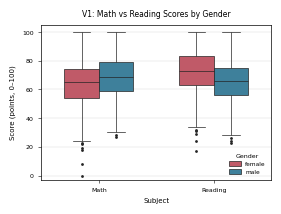

V1_gender_boxplots.png (800, 600)


math_score        reading_score       
             mean median          mean median
gender                                       
female      63.63   65.0         72.61   73.0
male        68.73   69.0         65.47   66.0

In [6]:
long = df.melt(id_vars='gender', value_vars=['math_score', 'reading_score'],
               var_name='subject', value_name='score')
long['subject'] = long['subject'].map({'math_score': 'Math', 'reading_score': 'Reading'})

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.boxplot(data=long, x='subject', y='score', hue='gender', hue_order=['female', 'male'],
            palette=PALETTE, width=0.6, linewidth=0.5, fliersize=1, ax=ax)
ax.set_title('V1: Math vs Reading Scores by Gender')
ax.set_xlabel('Subject')
ax.set_ylabel('Score (points, 0–100)')
ax.set_ylim(-3, 105)
ax.legend(title='Gender', loc='lower right', frameon=False)
ax.grid(axis='y', linewidth=0.3, alpha=0.5)
fig.tight_layout(pad=0.4)
save_fig(fig, 'V1_gender_boxplots.png')

v1 = df.groupby('gender')[['math_score', 'reading_score']].agg(['mean', 'median']).round(2)
v1

V2 - Test prep impact on math

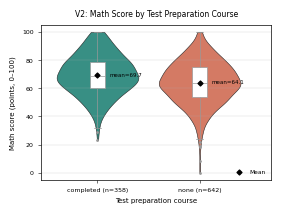

V2_testprep_math.png (800, 600)
                         count   mean  median    std
test_preparation_course                             
completed                  358  69.70    69.0  14.44
none                       642  64.08    64.0  15.19
Welch t = 5.79, p = 1.04e-08


In [7]:
order = ['completed', 'none']
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.violinplot(data=df, x='test_preparation_course', y='math_score', hue='test_preparation_course',
               order=order, palette=PALETTE, inner=None, linewidth=0.4, cut=0, legend=False, ax=ax)
sns.boxplot(data=df, x='test_preparation_course', y='math_score', order=order, width=0.15,
            color='white', linewidth=0.5, fliersize=1, ax=ax)
means = df.groupby('test_preparation_course')['math_score'].mean()
counts = df['test_preparation_course'].value_counts()
ax.scatter(range(len(order)), means[order], marker='D', s=6, color='black', zorder=5, label='Mean')
for i, g in enumerate(order):
    ax.text(i + 0.12, means[g], f'mean={means[g]:.1f}', fontsize=4, va='center')
ax.set_xticks(range(len(order)))
ax.set_xlim(-0.55, 1.7)
ax.set_xticklabels([f'{g} (n={counts[g]})' for g in order])
ax.set_title('V2: Math Score by Test Preparation Course')
ax.set_xlabel('Test preparation course')
ax.set_ylabel('Math score (points, 0–100)')
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='y', linewidth=0.3, alpha=0.5)
fig.tight_layout(pad=0.4)
save_fig(fig, 'V2_testprep_math.png')

from scipy import stats
v2 = df.groupby('test_preparation_course')['math_score'].agg(['count', 'mean', 'median', 'std']).round(2)
t_v2, p_v2 = stats.ttest_ind(df.loc[df.test_preparation_course=='completed', 'math_score'],
                             df.loc[df.test_preparation_course=='none', 'math_score'], equal_var=False)
print(v2); print(f'Welch t = {t_v2:.2f}, p = {p_v2:.2e}')

V3 — Lunch type and average performance

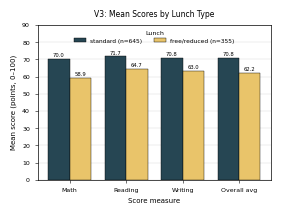

V3_lunch_overall_avg.png (800, 600)


,Math,Reading,Writing,Overall avg
lunch,,,,
standard,70.03,71.65,70.82,70.84
free/reduced,58.92,64.65,63.02,62.20


In [8]:
measures = {'math_score': 'Math', 'reading_score': 'Reading', 'writing_score': 'Writing', 'overall_avg': 'Overall avg'}
v3 = df.groupby('lunch')[list(measures)].mean().rename(columns=measures).loc[['standard', 'free/reduced']]
n_lunch = df['lunch'].value_counts()

fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(v3.columns)); w = 0.38
for i, lunch in enumerate(v3.index):
    bars = ax.bar(x + (i - 0.5) * w, v3.loc[lunch], w, color=PALETTE[lunch],
                  label=f'{lunch} (n={n_lunch[lunch]})', edgecolor='black', linewidth=0.3)
    ax.bar_label(bars, fmt='%.1f', fontsize=3.8, padding=1)
ax.set_xticks(x); ax.set_xticklabels(v3.columns)
ax.set_title('V3: Mean Scores by Lunch Type')
ax.set_xlabel('Score measure')
ax.set_ylabel('Mean score (points, 0–100)')
ax.legend(title='Lunch', loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.0))
ax.set_ylim(0, 90)
ax.grid(axis='y', linewidth=0.3, alpha=0.5); ax.set_axisbelow(True)
fig.tight_layout(pad=0.4)
save_fig(fig, 'V3_lunch_overall_avg.png')
v3.round(2)

V4 — Subject correlations

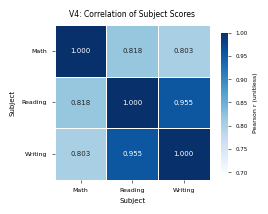

V4_subject_correlation_heatmap.png (800, 600)


,math_score,reading_score,writing_score
math_score,1.000,0.818,0.803
reading_score,0.818,1.000,0.955
writing_score,0.803,0.955,1.000


In [9]:
corr = df[score_cols].corr(method='pearson')
labels = ['Math', 'Reading', 'Writing']
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', vmin=0.7, vmax=1, square=True,
            xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor='white',
            annot_kws={'size': 5}, cbar_kws={'label': 'Pearson r (unitless)', 'shrink': 0.9}, ax=ax)
ax.collections[0].colorbar.ax.tick_params(labelsize=4, width=0.4, length=2)
ax.collections[0].colorbar.ax.yaxis.label.set_size(4.5)
ax.set_title('V4: Correlation of Subject Scores')
ax.set_xlabel('Subject'); ax.set_ylabel('Subject')
ax.tick_params(axis='y', rotation=0)
fig.tight_layout(pad=0.4)
save_fig(fig, 'V4_subject_correlation_heatmap.png')
corr.round(3)

V5 — Math vs reading with trend lines by test prep

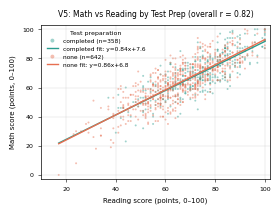

V5_math_vs_reading_by_prep.png (800, 600)
Interaction p-value (slope difference): 0.613


(               n  slope  intercept      r
 completed  358.0  0.840      7.597  0.793
 none       642.0  0.861      6.766  0.820,
 None)

In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE)
fits = {}
xs = np.linspace(df['reading_score'].min(), df['reading_score'].max(), 100)
for g in ['completed', 'none']:
    d = df[df['test_preparation_course'] == g]
    slope, intercept = np.polyfit(d['reading_score'], d['math_score'], 1)
    r_g = d['reading_score'].corr(d['math_score'])
    fits[g] = dict(n=len(d), slope=slope, intercept=intercept, r=r_g)
    ax.scatter(d['reading_score'], d['math_score'], s=2, alpha=0.45, color=PALETTE[g],
               edgecolors='none', label=f'{g} (n={len(d)})')
    ax.plot(xs, slope * xs + intercept, color=PALETTE[g], linewidth=1,
            label=f'{g} fit: y={slope:.2f}x{intercept:+.1f}')
r_all = df['reading_score'].corr(df['math_score'])
ax.set_title(f'V5: Math vs Reading by Test Prep (overall r = {r_all:.2f})')
ax.set_xlabel('Reading score (points, 0–100)')
ax.set_ylabel('Math score (points, 0–100)')
ax.set_xlim(10, 102); ax.set_ylim(-3, 103)
ax.legend(title='Test preparation', loc='upper left', frameon=False, markerscale=2)
ax.grid(linewidth=0.3, alpha=0.5)
fig.tight_layout(pad=0.4)
save_fig(fig, 'V5_math_vs_reading_by_prep.png')

# Formal test
import statsmodels.formula.api as smf
m = smf.ols('math_score ~ reading_score * C(test_preparation_course)', data=df).fit()
int_term = [k for k in m.params.index if ':' in k][0]
p_slope = m.pvalues[int_term]
pd.DataFrame(fits).T.round(3), print(f'Interaction p-value (slope difference): {p_slope:.3f}')

Stage 4 - Report

In [11]:
f, m_ = v1.loc['female'], v1.loc['male']
c, nn = v2.loc['completed'], v2.loc['none']
fc, fn = fits['completed'], fits['none']
gap_lunch = v3.loc['standard'] - v3.loc['free/reduced']

interp = {}
interp['V1'] = (
    f"Boys do better in math (average {m_[('math_score','mean')]:.1f} vs {f[('math_score','mean')]:.1f}). "
    f"Girls do better in reading (average {f[('reading_score','mean')]:.1f} vs {m_[('reading_score','mean')]:.1f}). "
    "So the gap depends on the subject. "
    "The boxes overlap a lot, so many girls and boys have similar scores. "
    "The lowest math score (0) belongs to a girl."
)
interp['V2'] = (
    f"Yes, students who finished test prep score higher in math. "
    f"Their average is {c['mean']:.1f}, compared with {nn['mean']:.1f} for students with no prep. "
    f"That is about {c['mean']-nn['mean']:.0f} points more, and the difference is significant (p < 0.001). "
    "The 'none' group has more very low scores. "
    "But the two shapes overlap a lot, so test prep alone does not decide the score."
)
interp['V3'] = (
    f"Students with standard lunch score higher in every subject. "
    f"Their overall average is {v3.loc['standard','Overall avg']:.1f}, compared with {v3.loc['free/reduced','Overall avg']:.1f} for free/reduced lunch. "
    f"The biggest gap is in math (about {gap_lunch['Math']:.0f} points). "
    "Free/reduced lunch often means the family has less money. "
    "So family income seems linked to test scores, but this does not prove lunch causes it."
)
interp['V4'] = (
    "All three subjects are strongly linked. "
    f"Reading and writing are almost the same (r = {corr.loc['reading_score','writing_score']:.2f}). "
    f"Math is also strongly linked to reading (r = {corr.loc['math_score','reading_score']:.2f}) and writing (r = {corr.loc['math_score','writing_score']:.2f}). "
    "This means a student who is good in one subject is usually good in the others. "
    "Math is a little less linked, maybe because it uses different skills."
)
interp['V5'] = (
    f"Math and reading are strongly linked (r = {r_all:.2f}): higher reading usually means higher math. "
    f"The completed group line has slope {fc['slope']:.2f} (n={fc['n']}). "
    f"The none group line has slope {fn['slope']:.2f} (n={fn['n']}). "
    f"The two lines are almost the same, and the difference is not significant (p = {p_slope:.2f}). "
    "So test prep does not change how math and reading are related."
)
for k, v in interp.items():
    print(k, len([s for s in v.split('. ') if s.strip()]), 'sentences')

V1 5 sentences
V2 5 sentences
V3 5 sentences
V4 5 sentences
V5 5 sentences


In [20]:
titles = {
 'V1': ('V1 — Gender boxplots (math vs reading)', 'Are there gender differences in math vs reading?', 'V1_gender_boxplots.png'),
 'V2': ('V2 — Test prep impact on math', 'Do students who completed test prep score higher in math?', 'V2_testprep_math.png'),
 'V3': ('V3 — Lunch type and average performance', 'Does lunch type (standard vs free/reduced) relate to outcomes?', 'V3_lunch_overall_avg.png'),
 'V4': ('V4 — Subject correlations', 'How strongly do the three subjects move together?', 'V4_subject_correlation_heatmap.png'),
 'V5': ('V5 — Math vs reading with trend lines by test prep',
        'How strongly are math and reading associated, and does test prep change the slope?', 'V5_math_vs_reading_by_prep.png'),
}
lines = ['# Findings — Student Performance (Question 2)', '',
 '## Data preparation',
 f'- Data: {df_raw.shape[0]} students, {df_raw.shape[1]} columns.',
 f'- Missing values: {int(df_raw.isna().sum().sum())}. Duplicate rows: {int(df_raw.duplicated().sum())}. All scores are between 0 and 100.',
 '- Added `overall_avg` = average of math, reading and writing.',
 '- All figures are 800×600 px, 300 DPI.', '']
for k, (t, q, fn_) in titles.items():
    lines += [f'## {t}', f'Q: {q}', f'A: {interp[k]}', '']
(REPORT_DIR/'findings.md').write_text('\n'.join(lines), encoding='utf-8')
print('\n'.join(lines))

# Findings — Student Performance (Question 2)

## Data preparation
- Data: 1000 students, 8 columns.
- Missing values: 0. Duplicate rows: 0. All scores are between 0 and 100.
- Added `overall_avg` = average of math, reading and writing.
- All figures are 800×600 px, 300 DPI.

## V1 — Gender boxplots (math vs reading)
Q: Are there gender differences in math vs reading?
A: Boys do better in math (average 68.7 vs 63.6). Girls do better in reading (average 72.6 vs 65.5). So the gap depends on the subject. The boxes overlap a lot, so many girls and boys have similar scores. The lowest math score (0) belongs to a girl.

## V2 — Test prep impact on math
Q: Do students who completed test prep score higher in math?
A: Yes, students who finished test prep score higher in math. Their average is 69.7, compared with 64.1 for students with no prep. That is about 6 points more, and the difference is significant (p < 0.001). The 'none' group has more very low scores. But the two shapes overlap a lot, 